In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and direc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# 선형 회귀모델 formula(y ~ X1 + X2 + ...)
import statsmodels.formula.api as smf
# 잔차의 정규성 확인 :qqplot, 회귀분석의 상수항 추가 : add_constant
from statsmodels.api import qqplot, add_constant
# 다중공선성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 학습용/평가용 데이터 분리:train, test
from sklearn.model_selection import train_test_split
# 선형회귀모형
from sklearn.linear_model import LinearRegression
# 변수 선택법(후진제거법)
from sklearn.feature_selection import RFE
# Scale 변환->표준화 회귀계수 산출
from sklearn.preprocessing import StandardScaler
# 평가함수
from sklearn.metrics import r2_score

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
car = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /real_final.csv')
car.head()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340


In [ ]:
#engine 열 삭제
car = car.drop('Engine', axis=1)
car

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Engine             5975 non-null   float64
 6   Seats              5975 non-null   float64
 7   Brand              5975 non-null   int64  
 8   Vehicle_Age        5975 non-null   int64  
 9   city_location      5975 non-null   int64  
 10  engine_group       5975 non-null   int64  
 11  log_price          5975 non-null   float64
 12  Power_log          5975 non-null   float64
dtypes: float64(5), int64(8)
memory usage: 607.0 KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 카테고리 변수를 숫자로 변환
car['engine_group'] = label_encoder.fit_transform(car['engine_group'])
car

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
car['engine_group'].unique()

array([0, 1, 2, 3])

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Seats              5975 non-null   float64
 6   Brand              5975 non-null   int64  
 7   Vehicle_Age        5975 non-null   int64  
 8   city_location      5975 non-null   int64  
 9   engine_group       5975 non-null   int64  
 10  log_price          5975 non-null   float64
 11  Power_log          5975 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 560.3 KB


In [ ]:
car

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


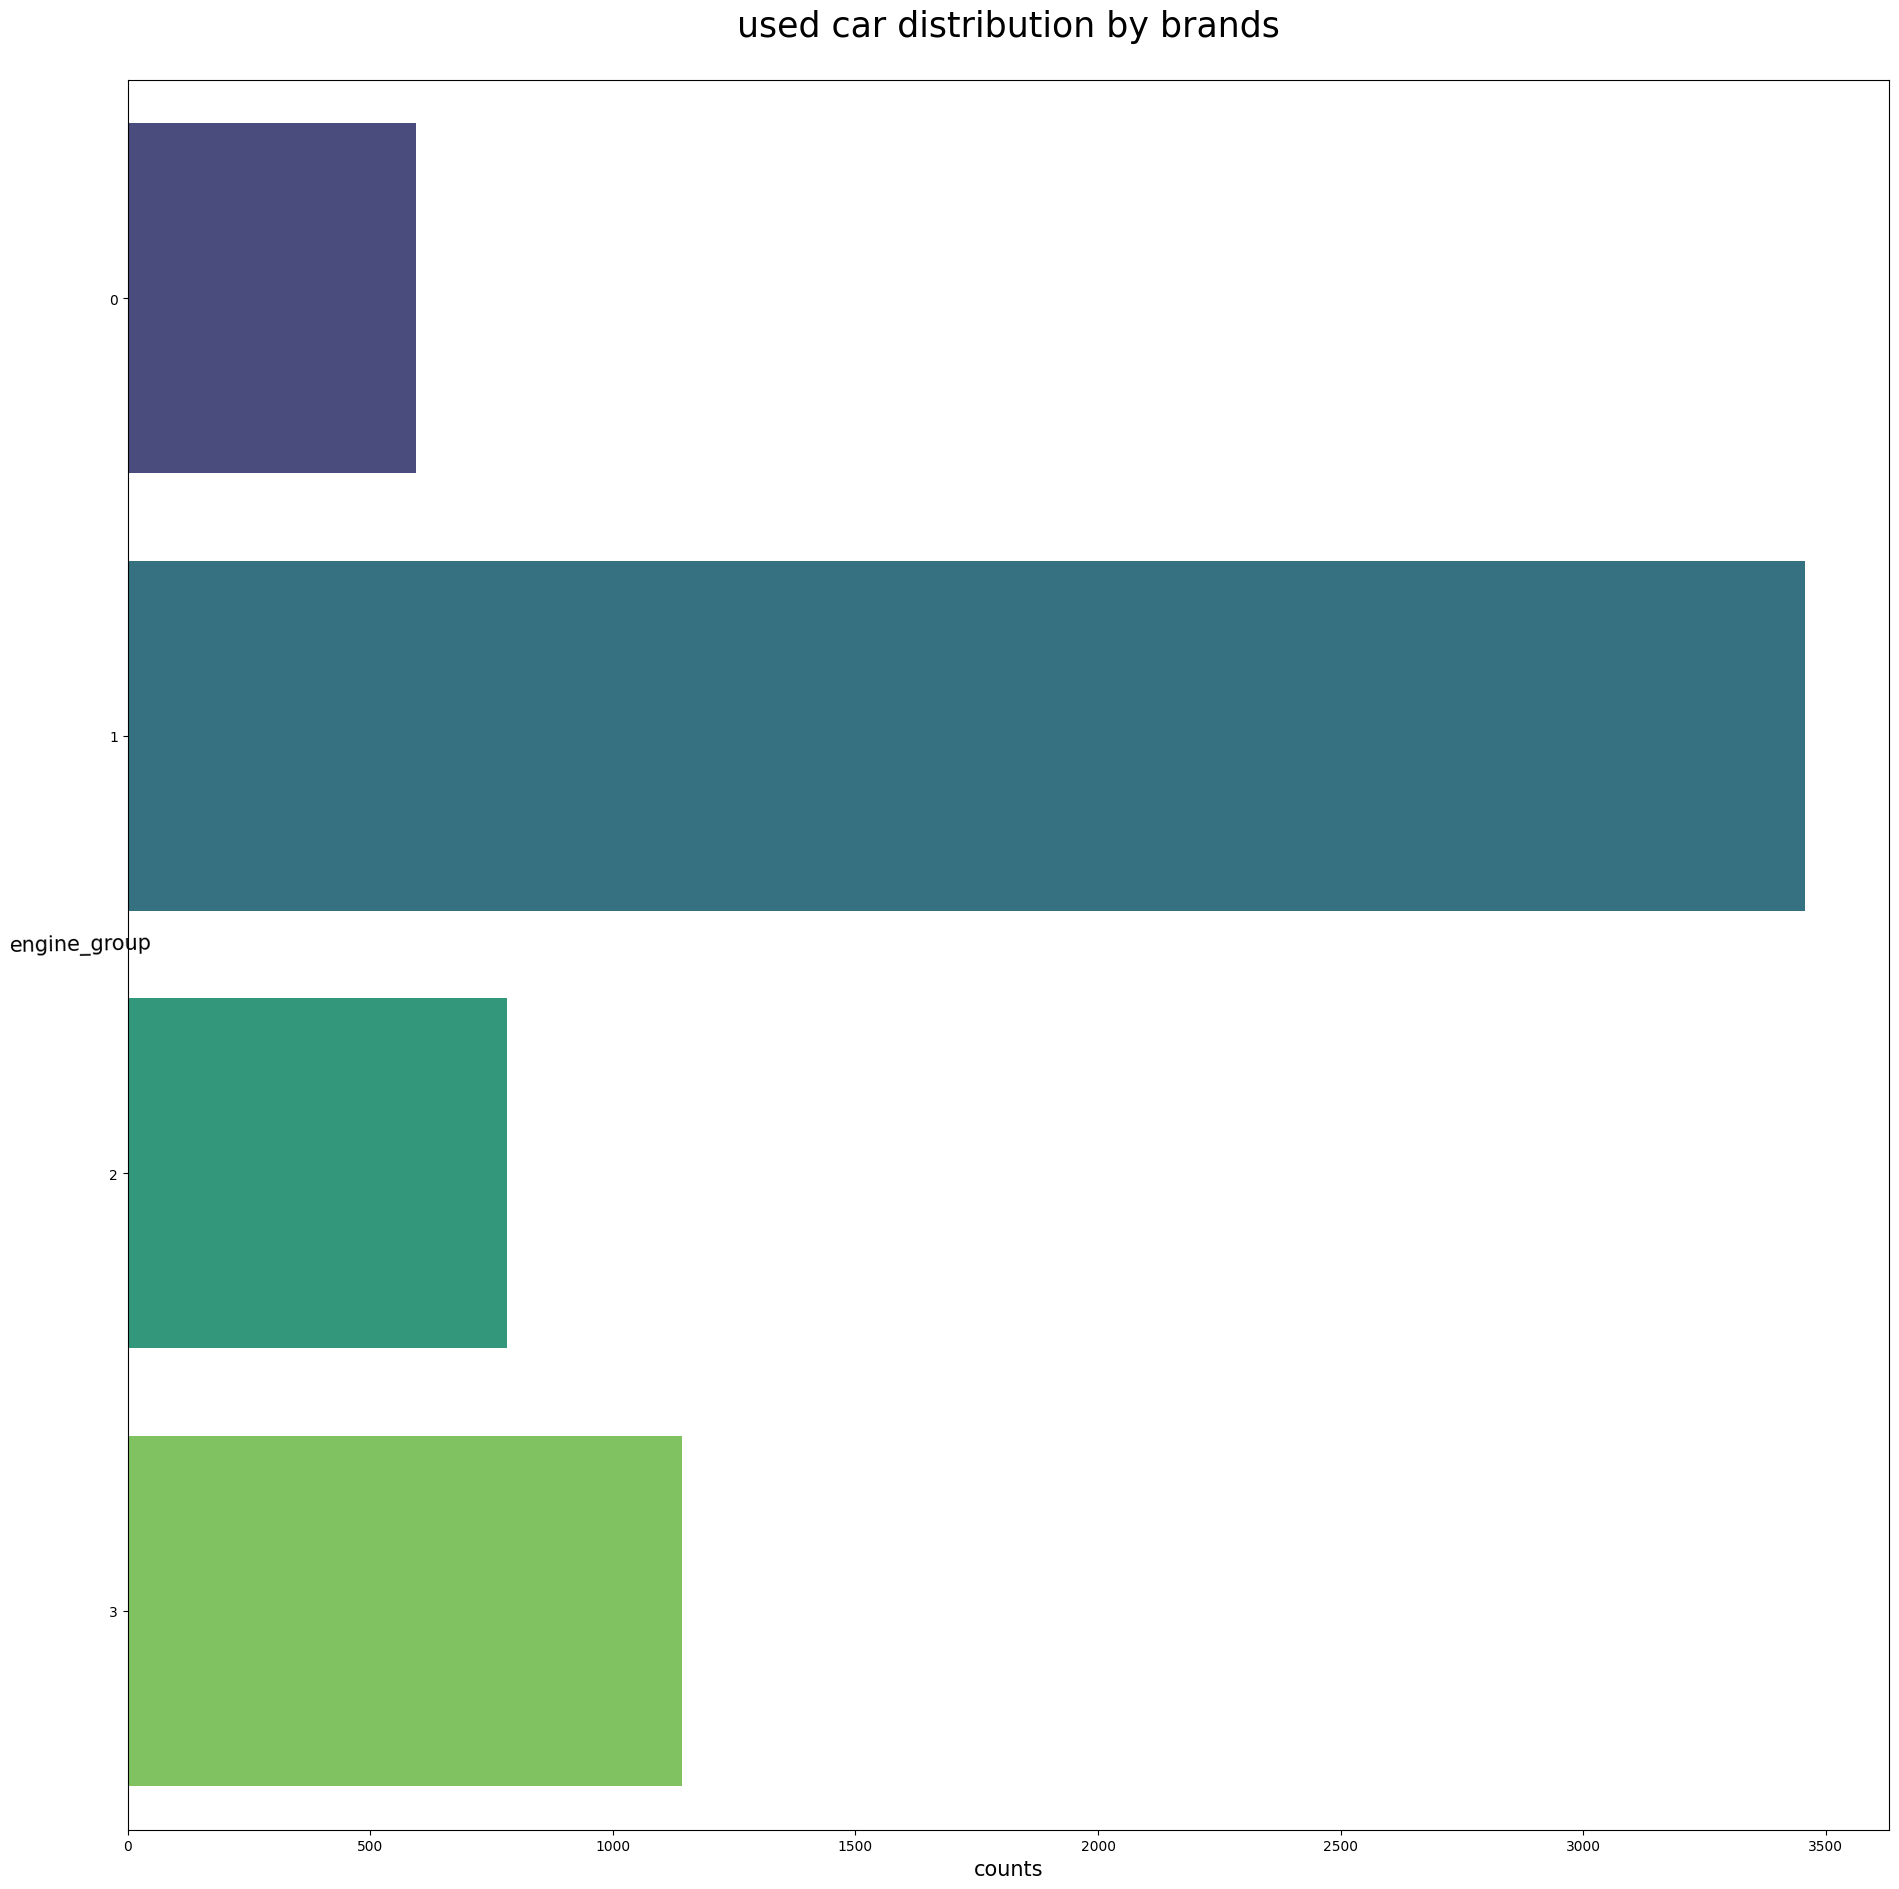

In [ ]:
plt.figure(figsize=(50,50))
plt.subplot(221)

sns.barplot(data=pd.DataFrame(car['engine_group'].value_counts()).T, palette='viridis', ci=False, orient='h')

plt.title('used car distribution by brands', fontsize=25, y=1.02)
plt.xlabel('counts', fontsize=15)
plt.ylabel('engine_group', fontsize=15, rotation=1, labelpad=20)

plt.show()

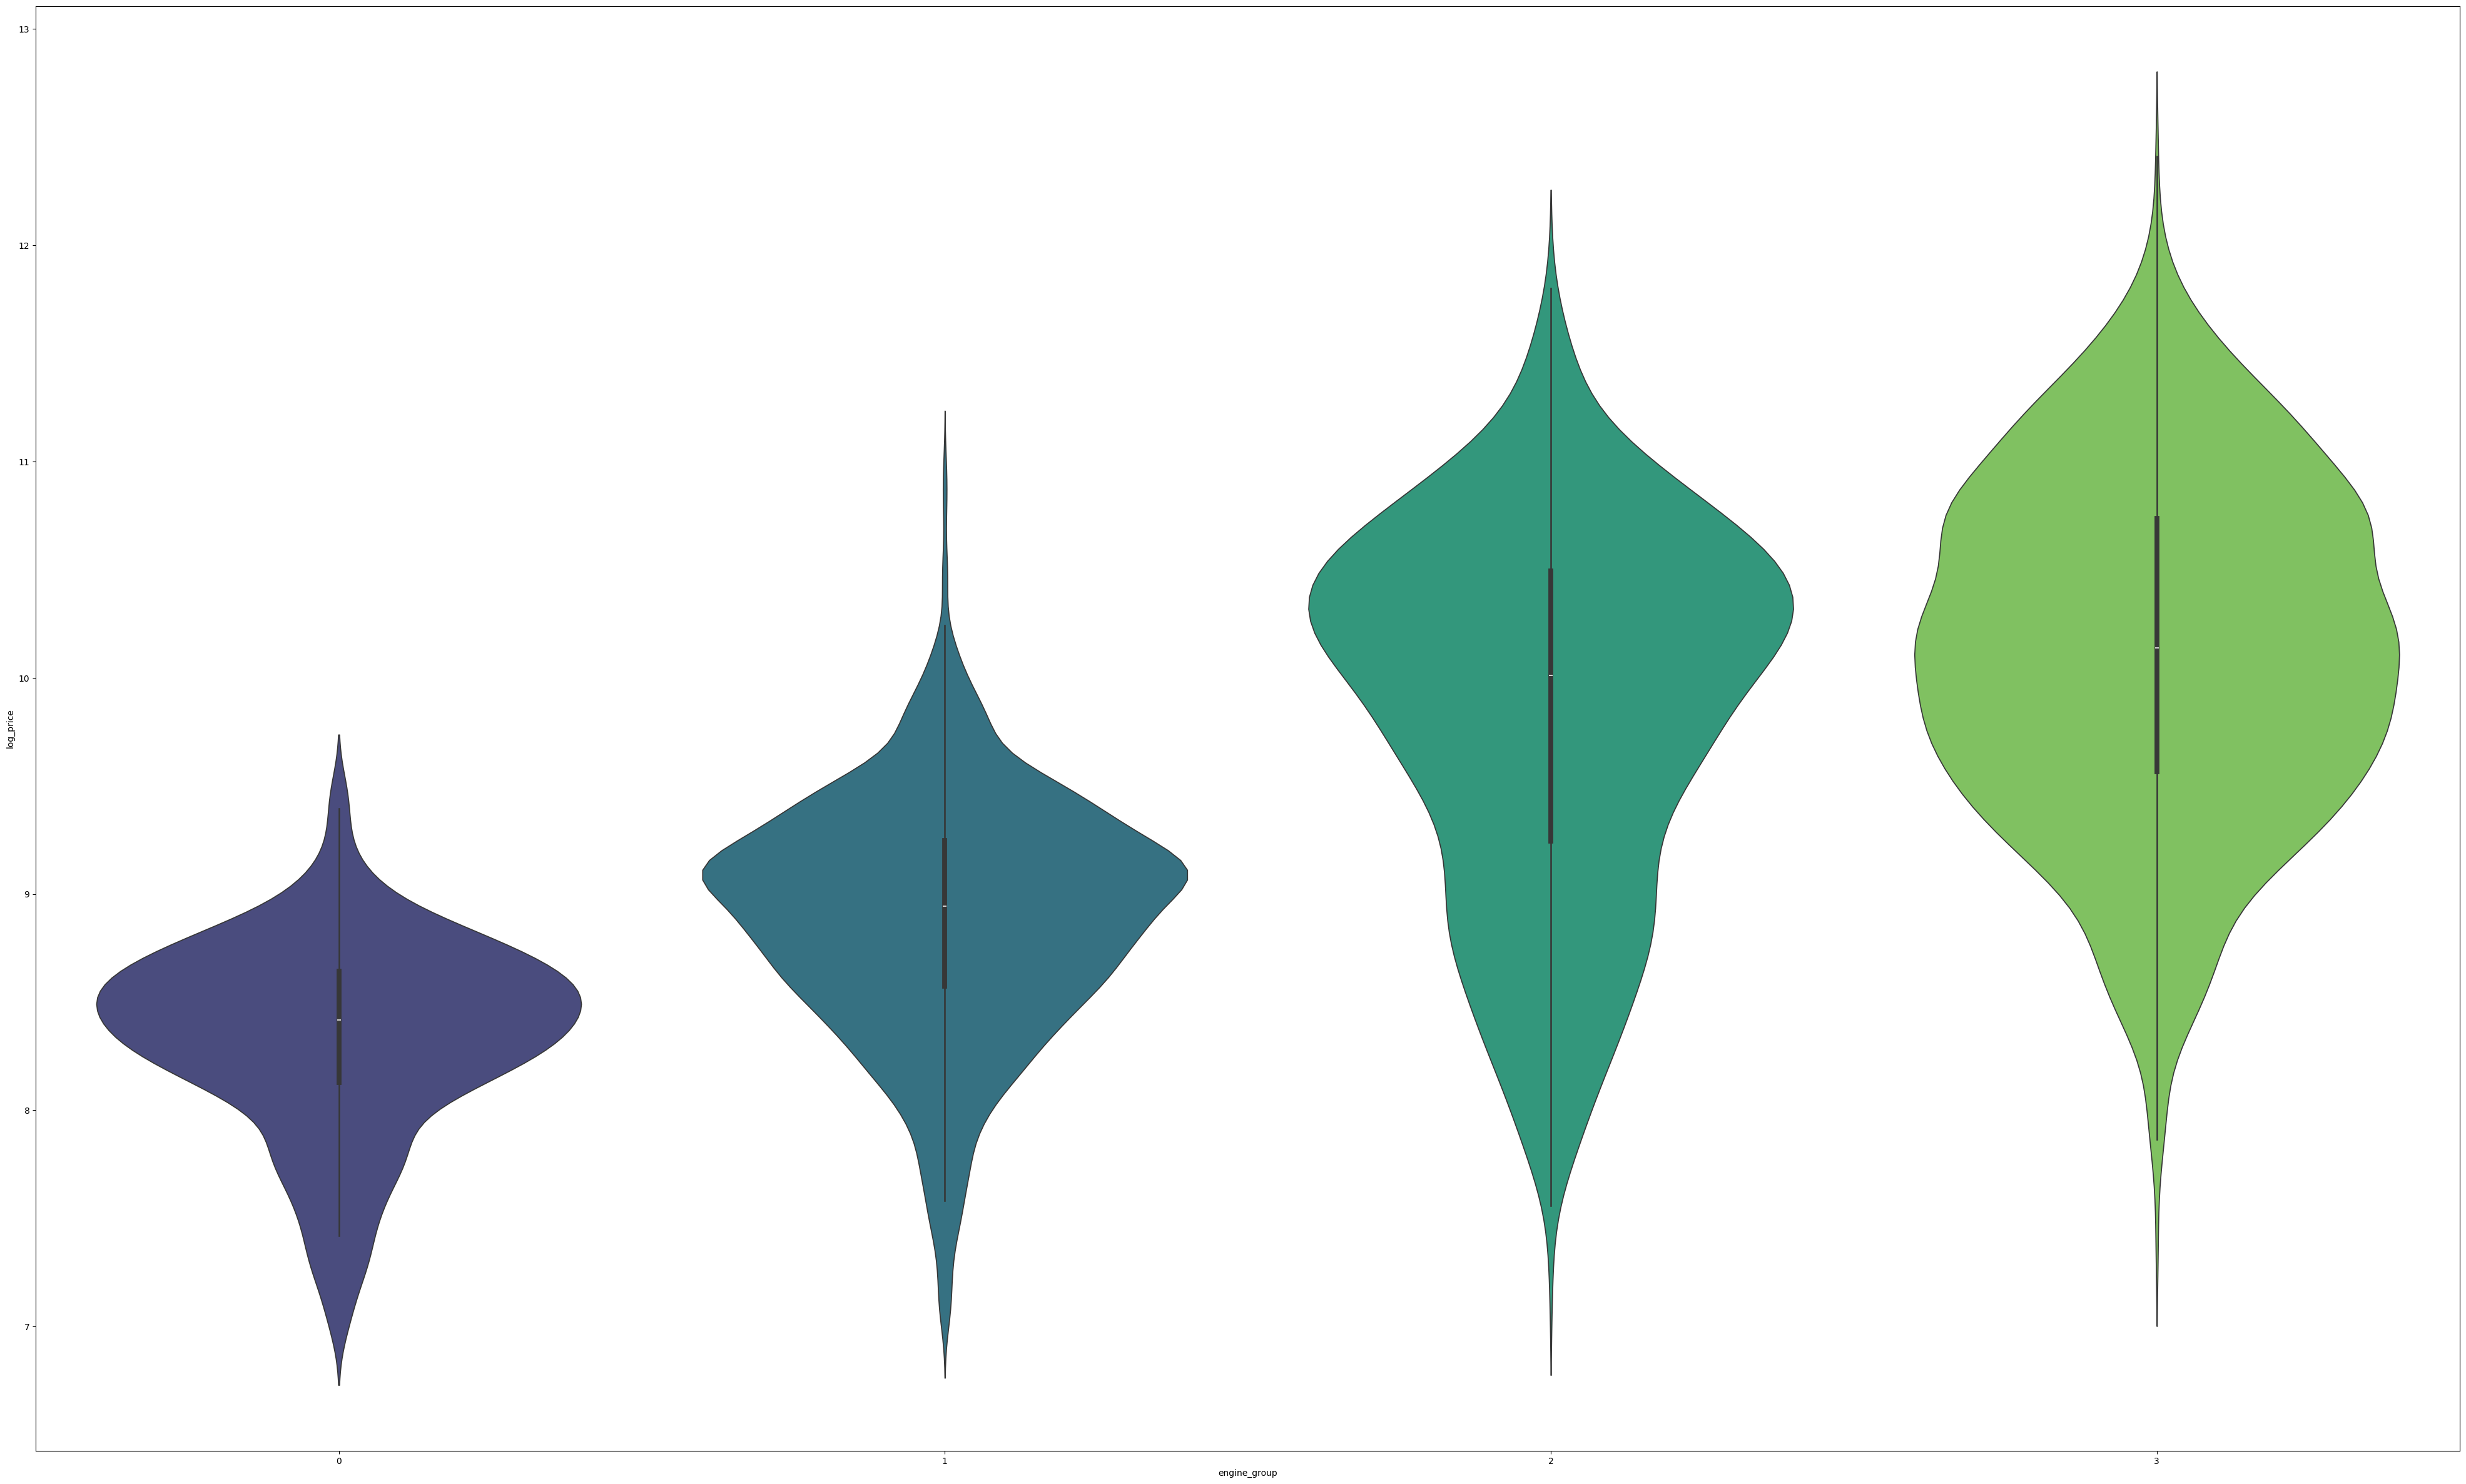

In [ ]:
plt.figure(figsize=(50,30))
sns.violinplot(data=car, x="engine_group", y="log_price", palette='viridis')
plt.show()

Text(0.5, 1.0, 'Brand')

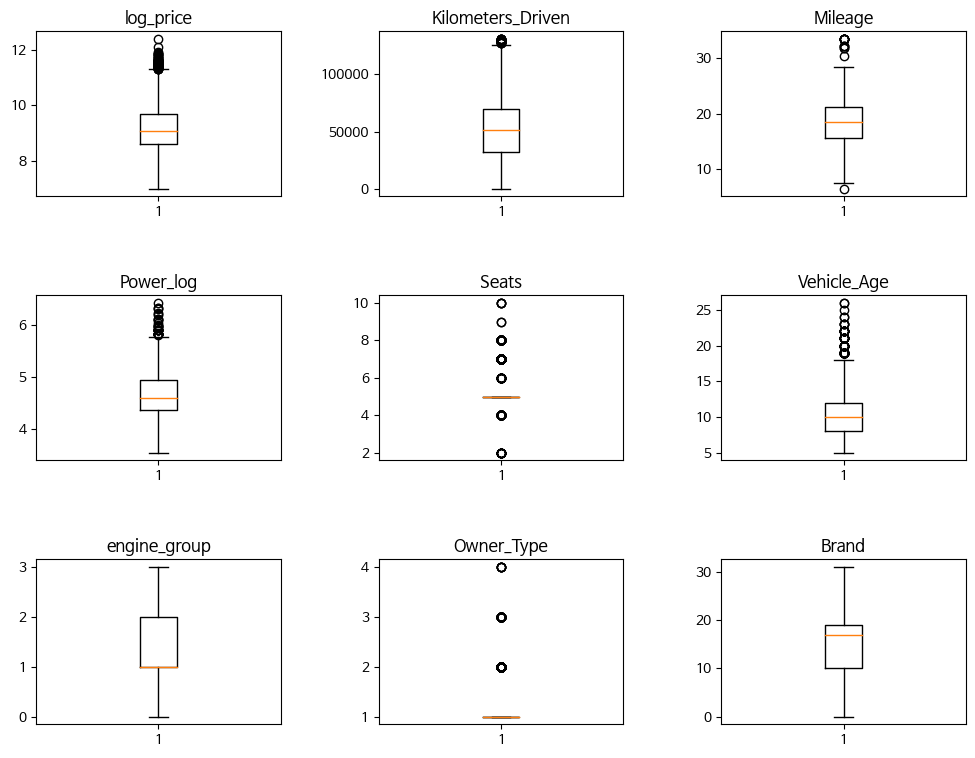

In [ ]:
#box-plot
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
axs = axs.flatten()

fig.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0].boxplot(car['log_price'])
axs[0].set_title('log_price')

axs[1].boxplot(car['Kilometers_Driven'])
axs[1].set_title('Kilometers_Driven')

axs[2].boxplot(car['Mileage'])
axs[2].set_title('Mileage')


axs[3].boxplot(car['Power_log'])
axs[3].set_title('Power_log')

axs[4].boxplot(car['Seats'])
axs[4].set_title('Seats')

axs[5].boxplot(car['Vehicle_Age'])
axs[5].set_title('Vehicle_Age')


axs[6].boxplot(car['engine_group'])
axs[6].set_title('engine_group')

axs[7].boxplot(car['Owner_Type'])
axs[7].set_title('Owner_Type')

axs[8].boxplot(car['Brand'])
axs[8].set_title('Brand')

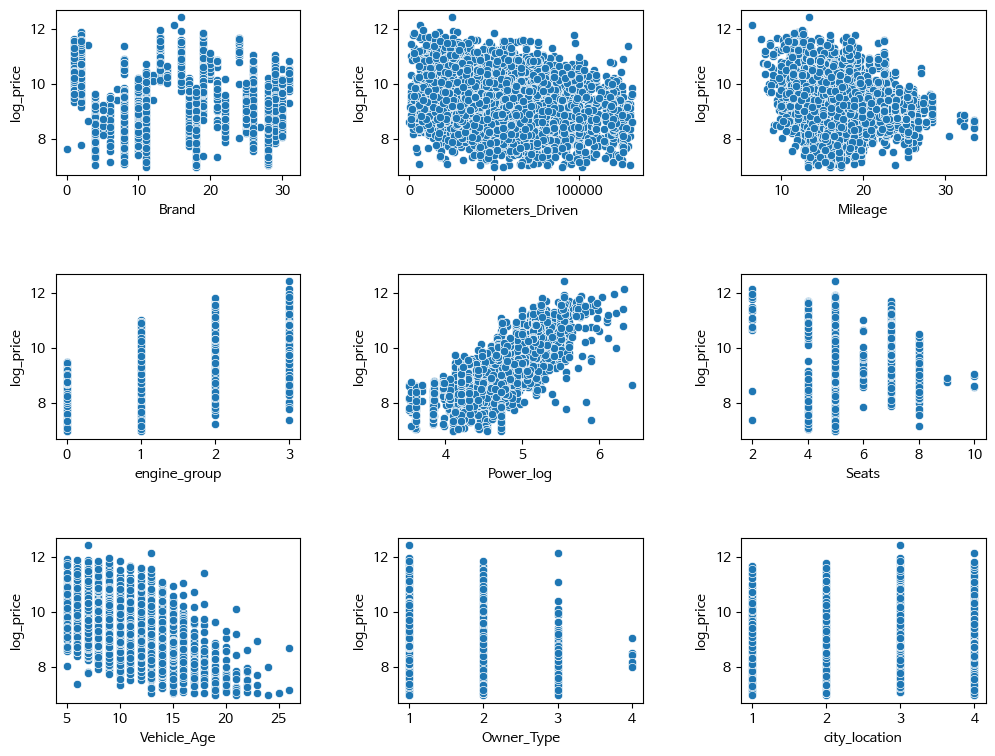

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
axs = axs.flatten()

sns.scatterplot(data=car, x='Brand', y='log_price', ax=axs[0])
sns.scatterplot(data=car, x='Kilometers_Driven', y='log_price', ax=axs[1])
sns.scatterplot(data=car, x='Mileage', y='log_price', ax=axs[2])
sns.scatterplot(data=car, x='engine_group', y='log_price', ax=axs[3])
sns.scatterplot(data=car, x='Power_log', y='log_price', ax=axs[4])
sns.scatterplot(data=car, x='Seats', y='log_price', ax=axs[5])
sns.scatterplot(data=car, x='Vehicle_Age', y='log_price', ax=axs[6])
sns.scatterplot(data=car, x='Owner_Type', y='log_price', ax=axs[7])
sns.scatterplot(data=car, x='city_location', y='log_price', ax=axs[8])

fig.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

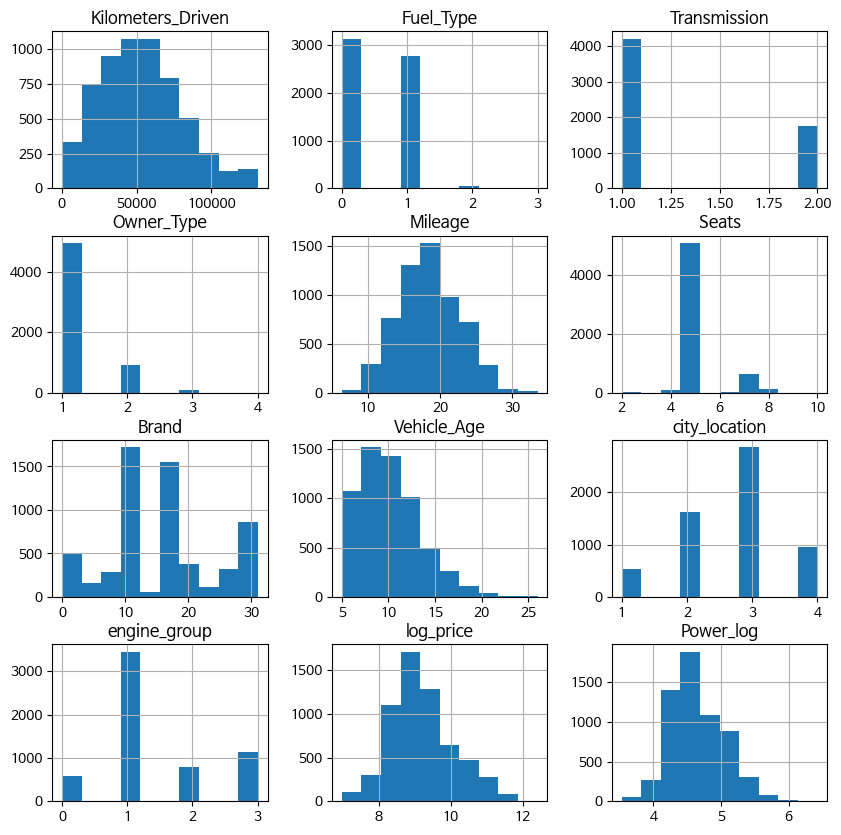

In [ ]:
car.hist(figsize = (10, 10)) #히스토그램 - 데이터의 전반적인 분포를 파악
fig.subplots_adjust(wspace=0.4, hspace=0.8)

<Axes: >

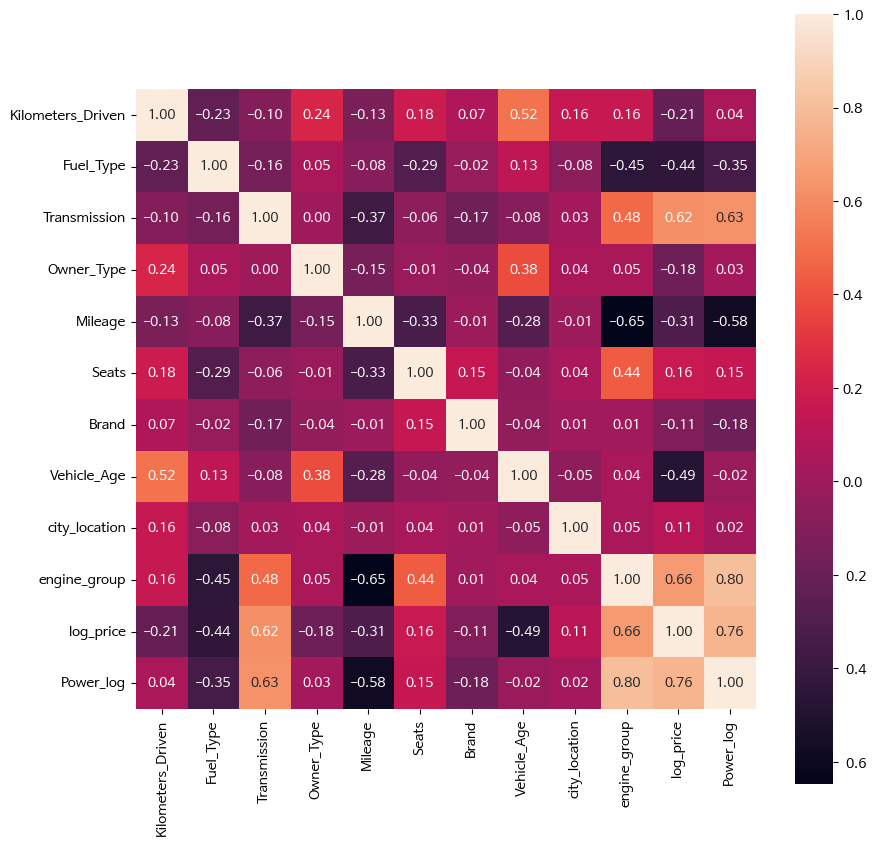

In [ ]:
car = car.select_dtypes(include=np.number) #car에서 수치형 열만 선택
plt.figure(figsize=(10, 10))
sns.heatmap(car.corr(), annot=True, square=True, fmt='.2f', annot_kws={'size': 10})
#annot=True는 히트맵 셀에 상관계수 값을 표시,

# 브랜드 변수 검정

In [ ]:
from scipy.stats import shapiro, normaltest

# 각 'Brand_Group' 범주별로 'Log_price' 데이터의 정규성 검정
for brand in car['engine_group'].unique():
    stat, p = shapiro(car[car['engine_group'] == brand]['log_price'])
    print(f"Shapiro test for {brand}: Statistics={stat}, p-value={p}")

Shapiro test for 0: Statistics=0.9667094349861145, p-value=2.3534946214098795e-10
Shapiro test for 1: Statistics=0.9871975779533386, p-value=3.7453235976408697e-17
Shapiro test for 2: Statistics=0.9679930210113525, p-value=4.733175656967958e-12
Shapiro test for 3: Statistics=0.9944791793823242, p-value=0.00032794199069030583


해석:

검정 통계량은 0에서 1 사이의 값을 가지며, 1에 가까울수록 데이터가 정규 분포를 따른다는 것을 의미합니다.
p-value는 귀무가설(데이터가 정규 분포를 따른다)에 대한 확률로, 일반적으로 0.05보다 작으면 귀무가설을 기각하게 됩니다.
결과를 종합하면, 모든 엔진 그룹에 대해 p-value가 매우 작아서 귀무가설을 기각할 수 있습니다. 따라서 주어진 데이터는 정규 분포를 따르지 않는 것으로 나타납니다.







In [ ]:
from scipy.stats import kruskal

# 엔진 그룹에 따른 'price'의 평균 비교를 위한 Kruskal-Wallis 검정
result_kruskal = kruskal(car[car['engine_group'] == 0]['log_price'],
                         car[car['engine_group'] == 1]['log_price'],
                         car[car['engine_group'] == 2]['log_price'],
                         car[car['engine_group'] == 3]['log_price'])

# Kruskal-Wallis 검정 결과 출력
print("Kruskal-Wallis Test Result:")
print("H-statistic:", result_kruskal.statistic)
print("p-value:", result_kruskal.pvalue)


Kruskal-Wallis Test Result:
H-statistic: 2554.8156845355447
p-value: 0.0


해석:

Kruskal-Wallis 검정 결과, 그룹 간의 중앙값이 적어도 하나는 다른 그룹과 유의하게 다르다는 강력한 증거가 있습니다.
p-value가 0으로 매우 작기 때문에 귀무가설을 기각하고, 그룹 간의 중앙값이 동일하다는 가정을 받아들이기 어렵다는 것을 의미합니다.
따라서 적어도 하나의 엔진 그룹의 'price' 중앙값이 다른 그룹과 다르다고 할 수 있습니다.

In [ ]:
car.corr().round(3)

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
Kilometers_Driven,1.000,-0.230,-0.097,0.238,-0.127,0.179,0.066,0.516,0.163,0.157,-0.212,0.042
Fuel_Type,-0.230,1.000,-0.159,0.051,-0.082,-0.288,-0.025,0.130,-0.079,-0.449,-0.438,-0.348
Transmission,-0.097,-0.159,1.000,0.002,-0.373,-0.058,-0.168,-0.085,0.027,0.485,0.619,0.632
Owner_Type,0.238,0.051,0.002,1.000,-0.147,-0.013,-0.041,0.384,0.044,0.046,-0.184,0.026
Mileage,-0.127,-0.082,-0.373,-0.147,1.000,-0.327,-0.008,-0.280,-0.006,-0.648,-0.307,-0.580
Seats,0.179,-0.288,-0.058,-0.013,-0.327,1.000,0.155,-0.043,0.039,0.440,0.165,0.152
Brand,0.066,-0.025,-0.168,-0.041,-0.008,0.155,1.000,-0.042,0.012,0.009,-0.109,-0.183
Vehicle_Age,0.516,0.130,-0.085,0.384,-0.280,-0.043,-0.042,1.000,-0.054,0.036,-0.487,-0.016
city_location,0.163,-0.079,0.027,0.044,-0.006,0.039,0.012,-0.054,1.000,0.049,0.106,0.024
engine_group,0.157,-0.449,0.485,0.046,-0.648,0.440,0.009,0.036,0.049,1.000,0.661,0.801


In [ ]:
# train/test data 분리
car_train, car_test = train_test_split(car, test_size = 0.2, random_state = 1234)
print("train data size : {}".format(car_train.shape))
print("test data size : {}".format(car_test.shape))

train data size : (4780, 12)
test data size : (1195, 12)


In [ ]:
reg_model = smf.ols(formula = "log_price ~  Kilometers_Driven + Fuel_Type  + Transmission  + \
            Mileage  +Seats + Brand  + city_location + Power_log + engine_group", data = car_train)
# 적합
reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     1677.
Date:                Sat, 09 Mar 2024   Prob (F-statistic):               0.00
Time:                        13:49:34   Log-Likelihood:                -2692.4
No. Observations:                4780   AIC:                             5405.
Df Residuals:                    4770   BIC:                             5470.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.4767      0.17

모든 변수 유의수준에서 유의!

In [ ]:
# 설명변수간의 다중공선성 확인 : 설명변수 데이터 생성 및 상수항 추가
car_train_x = car_train.drop(['log_price','Owner_Type','Vehicle_Age'], axis = 1)
# statsmodels의 상수항 추가 함수 적용
car_train_x_const = add_constant(car_train_x)
# DataFrame으로 저장
car_vif = pd.DataFrame()
car_vif["variable"] = car_train_x_const.columns
car_vif["VIF"] = [variance_inflation_factor(car_train_x_const.values, i) \
                 for i in range(car_train_x_const.shape[1])]
# VIF 정렬
car_vif.sort_values("VIF", ascending = True).round(2)

,variable,VIF
7,city_location,1.03
6,Brand,1.12
1,Kilometers_Driven,1.17
5,Seats,1.61
3,Transmission,1.80
2,Fuel_Type,1.98
4,Mileage,2.76
9,Power_log,4.20
8,engine_group,5.12
0,const,850.55


다중공선성 5 이하로 다중공선성 없는 거 확인!

Price = 5.47 -0.2Fuel_Type +0.33Transmission-0.6Owner_Type-0.27Seats-0.001Brand-0.12Vehicle_Age+0.06city_location+0.97Power_log+0.18engine_group

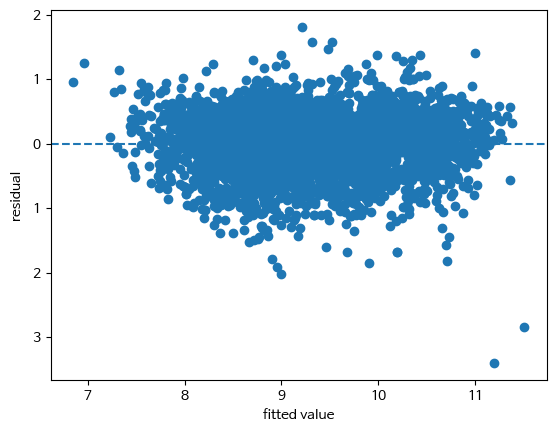

In [ ]:
#잔차 산점도 확인
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value")
plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

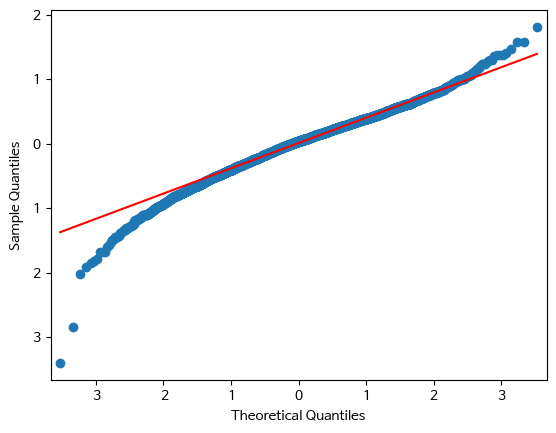

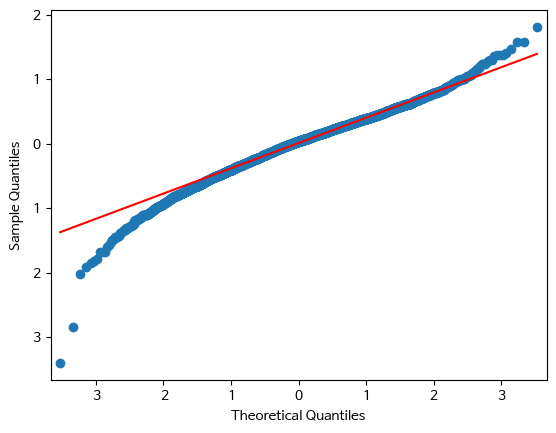

In [ ]:
#잔차 정규성 검정: q-q plot, s-standardized line
qqplot(reg_result.resid, line = "q")

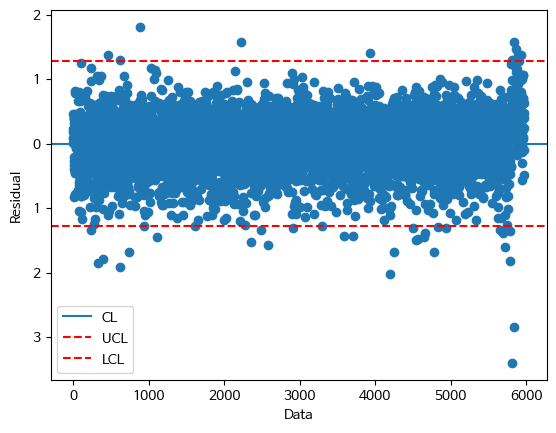

In [ ]:
# 잔차의 독립성 확인
plt.scatter(car_train.index, reg_result.resid)
plt.xlabel("Data")  ;  plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend()

In [ ]:
# 평가용 데이터에 대한 성능 확인
train_pred = reg_result.predict(car_train)
test_pred = reg_result.predict(car_test)
print("train data의 결정계수:", r2_score(car_train['log_price'], train_pred))
print("test data의 결정계수:", r2_score(car_test['log_price'], test_pred))

train data의 결정계수: 0.7598150633392878
test data의 결정계수: 0.7495470662408349


In [ ]:
from sklearn.metrics import mean_squared_error

# 훈련 데이터와 테스트 데이터에 대한 예측값 계산
train_pred = reg_result.predict(car_train)
test_pred = reg_result.predict(car_test)

# 훈련 데이터와 테스트 데이터에 대한 MSE 계산
train_mse = mean_squared_error(car_train['log_price'], train_pred)
test_mse = mean_squared_error(car_test['log_price'], test_pred)

print("train data의 MSE:", train_mse)
print("test data의 MSE:", test_mse)


train data의 MSE: 0.18062479996436592
test data의 MSE: 0.1947493731086118


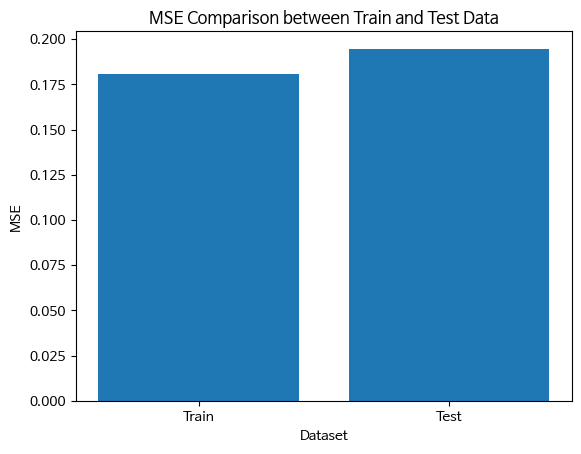

In [ ]:
# 그래프 그리기
plt.bar(['Train', 'Test'], [train_mse, test_mse])
plt.xlabel('Dataset')
plt.ylabel('MSE')
plt.title('MSE Comparison between Train and Test Data')
plt.show()

In [ ]:
Intercept             2.4767      0.179     13.801      0.000       2.125       2.829
Kilometers_Driven  -9.44e-06   2.45e-07    -38.597      0.000   -9.92e-06   -8.96e-06
Fuel_Type            -0.2696      0.016    -16.483      0.000      -0.302      -0.238
Transmission          0.4096      0.018     22.659      0.000       0.374       0.445
Mileage               0.0355      0.002     14.392      0.000       0.031       0.040
Seats                 0.0712      0.010      7.115      0.000       0.052       0.091
Brand                 0.0033      0.001      4.094      0.000       0.002       0.005
city_location         0.1160      0.007     15.618      0.000       0.101       0.131
Power_log             1.1170      0.031     36.380      0.000       1.057       1.177
engine_group          0.1746      0.015     11.371      0.000       0.144       0.205

Price = 2.48-0.27Fuel_Type +0.40Transmission+0.03Mileage +0.07Seats+0.003Brand+0.116city_location+1.12Power_log +0.17engine_group

<h2>통계적 검정 후 유의한 변수들로만 다중선형회귀 결론</h2>


다중선형회귀 의 최종 성능:  
- train : 0.759
- test : 0.749

MSE값:
- train : 0.180
- test : 0.194


최종 모형에 사용된 변수:

- Kilometers_Driven
- Fuel_Type  
- Transmission  
-  Mileage  
- Seats
- Brand
- city_location
-  Power_log
- engine_group

최종 회귀식:

Price = 2.48-0.27Fuel_Type +0.40Transmission+0.03Mileage +0.07Seats+0.003Brand+0.116city_location+1.12Power_log +0.17engine_group
